# Bank Marketing EDA

## 1. Problem Definition and Data-Generating Process

### 1.1 Business Problem

The objective is to identify clients who are more likely to subscribe to a bank term deposit before a marketing call is made.

The prediction will be used to prioritize clients when marketing resources, such as available call-center agents, are limited.

Rather than treating the task only as a binary classification problem, the model should ideally produce a probability or ranking that can support client prioritization.

### 1.2 Prediction Target

The target variable is:

- `y = "yes"`: the client subscribed to a term deposit.
- `y = "no"`: the client did not subscribe to a term deposit.

This is a binary classification problem.

### 1.3 Prediction Timestamp

The intended prediction time is immediately before a marketing call is made.

Conceptually:

Client information and historical information
→ Model prediction
→ Marketing call
→ Call outcome
→ Term-deposit subscription outcome

Only information that is available before the marketing call should be used as model input.

### 1.4 Unit of Observation

Each row represents a marketing campaign observation associated with a bank client.

A row contains a combination of:

- client characteristics
- current campaign information
- previous campaign history
- social and economic context
- subscription outcome

The dataset does not contain a unique client identifier, so repeated observations from the same client cannot be directly identified.

### 1.5 Data-Generating Process

The dataset was collected from direct marketing campaigns conducted by a Portuguese banking institution.

A simplified data-generating process is:

1. The bank has information about a client.
2. A marketing campaign targets the client.
3. The client may be contacted one or more times.
4. Contact-related information is recorded.
5. The client either subscribes or does not subscribe to a term deposit.
6. The final campaign record is stored in the dataset.

Some variables may therefore be generated before the prediction time, while others may only become known during or after the marketing contact.

This distinction will be important when checking feature availability and data leakage.

### 1.6 Business Decision

The model will not be used only to predict a label.

The intended decision is to prioritize clients for marketing calls.

For example, if only a limited number of clients can be contacted, clients with the highest predicted subscription probabilities could be contacted first.

Therefore, probability ranking, threshold selection, and top-k decision rules may be more relevant than classification accuracy alone.

## 2. Dataset Overview and Schema

This section examines the basic structure of the dataset.

The goals are to:

- confirm the dataset shape
- inspect sample observations
- inspect column names
- inspect data types
- identify numeric and categorical variables
- confirm the target variable

In [135]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
PROJECT_ROOT = Path.cwd().parent
PROJECT_ROOT

PosixPath('/home/moonk/projects/bank-marketing-ml')

In [5]:
RAW_DATA_PATH = (
    PROJECT_ROOT
     / "data"
     / "raw"
     / "bank-additional"
     / "bank-additional-full.csv"
    )

RAW_DATA_PATH

PosixPath('/home/moonk/projects/bank-marketing-ml/data/raw/bank-additional/bank-additional-full.csv')

In [6]:
df = pd.read_csv(RAW_DATA_PATH, sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
df.shape

(41188, 21)

In [51]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [52]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

In [53]:
df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [56]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(include="str").columns.tolist()

In [57]:
numeric_cols

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [58]:
categorical_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

In [59]:
len(numeric_cols), len(categorical_cols)

(10, 11)

In [61]:
target_col = "y"

### Observations

- The dataset contains 41,188 rows and 21 columns.
- There are 20 input variables and 1 target variable.
- The target variable is `y`.
- Numeric and categorical variables are both present.
- The dataset contains a mix of client attributes, campaign-related variables, previous campaign information, and macroeconomic variables.

## 3. Data Quality Checks

This section checks the dataset for common data quality issues.

The goals are to examine:

- missing values
- special or unknown categories
- exact duplicate rows
- unusual or invalid values
- categorical cardinality
- special sentinel values

### 3.1 Missing Values

In [11]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

### 3.2 Special or Unknown Categories

In [62]:
for col in categorical_cols:
    unknown_rate = (df[col] == "unknown").mean()

    if unknown_rate > 0:
        print(f"{col}: {unknown_rate:.2%}")

job: 0.80%
marital: 0.19%
education: 4.20%
default: 20.87%
housing: 2.40%
loan: 2.40%


### 3.3 Exact duplicate rows

In [63]:
df.duplicated().sum()

np.int64(12)

In [64]:
df[df.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


### 3.4 Categorical Cardinality

In [67]:
df.nunique().sort_values()

contact              2
y                    2
default              3
loan                 3
poutcome             3
housing              3
marital              4
day_of_week          5
previous             8
education            8
emp.var.rate        10
month               10
nr.employed         11
job                 12
cons.price.idx      26
cons.conf.idx       26
pdays               27
campaign            42
age                 78
euribor3m          316
duration          1544
dtype: int64

### 3.5 Unusual or Invalid Values

In [70]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### 3.6 Special Sentinel Values

In [73]:
df["pdays"].value_counts().sort_index()

pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64

In [74]:
(df["pdays"] == 999).mean()

np.float64(0.9632174419733903)

In [75]:
pd.crosstab(
    df["poutcome"],
    df["pdays"].eq(999),
)

pdays,False,True
poutcome,,
failure,142,4110
nonexistent,0,35563
success,1373,0


In [76]:
pd.crosstab(
    df["poutcome"],
    df["previous"],
)

previous,0,1,2,3,4,5,6,7
poutcome,,,,,,,,
failure,0,3696,434,88,30,3,1,0
nonexistent,35563,0,0,0,0,0,0,0
success,0,865,320,128,40,15,4,1


### Observations

- No pandas-recognized missing values were found.
- Several categorical variables contain the value `"unknown"`.
- `"unknown"` is especially common in `default`.
- Exact duplicate rows are present, but they are not removed at this stage because the dataset does not contain a unique client identifier.
- `pdays` contains a special sentinel value, `999`.
- `pdays`, `previous`, and `poutcome` should be interpreted together because they describe previous campaign history.
- No obvious invalid numeric ranges were observed at this stage.

## 4. Target Analysis

This section examines the distribution of the target variable `y`.

The goals are to:

- inspect class counts
- inspect class proportions
- assess class imbalance
- identify implications for model evaluation

In [77]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [78]:
df["y"].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

<Axes: title={'center': 'Target Distribution'}, xlabel='y'>

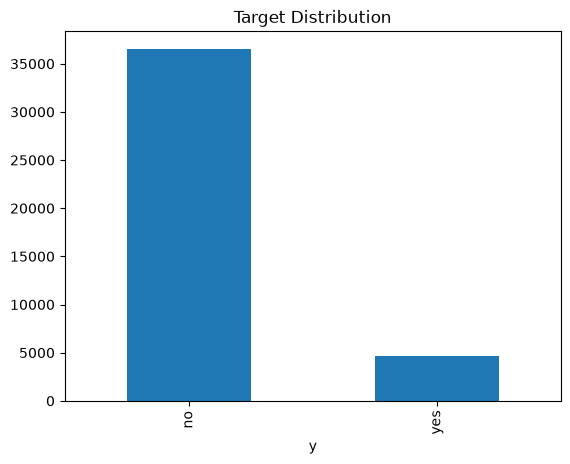

In [79]:
df["y"].value_counts().plot(
    kind="bar",
    title="Target Distribution",
)

### Observations

- The target variable is imbalanced.
- Approximately 88.7% of observations belong to the `no` class.
- Approximately 11.3% belong to the `yes` class.
- A naive classifier that predicts `no` for every observation would achieve high accuracy despite having no practical predictive value.
- Accuracy alone will therefore not be sufficient for model evaluation.
- Metrics such as ROC-AUC, PR-AUC, precision, and recall should be considered during model evaluation.
- Because the business objective involves prioritizing clients for marketing calls, predicted probabilities and ranking-based decision rules may also be important.

## 5. Univariate Analysis

This section examines each feature independently.

The goals are to:

- understand the distribution of numeric variables
- identify skewness and extreme values
- inspect the frequency of categorical variables
- identify rare categories and low-cardinality variables
- detect special values that may require preprocessing later

### 5.1 Numercial Features

In [84]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [86]:
df[numeric_cols].describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>],
       [<Axes: title={'center': 'pdays'}>,
        <Axes: title={'center': 'previous'}>,
        <Axes: title={'center': 'emp.var.rate'}>],
       [<Axes: title={'center': 'cons.price.idx'}>,
        <Axes: title={'center': 'cons.conf.idx'}>,
        <Axes: title={'center': 'euribor3m'}>],
       [<Axes: title={'center': 'nr.employed'}>, <Axes: >, <Axes: >]],
      dtype=object)

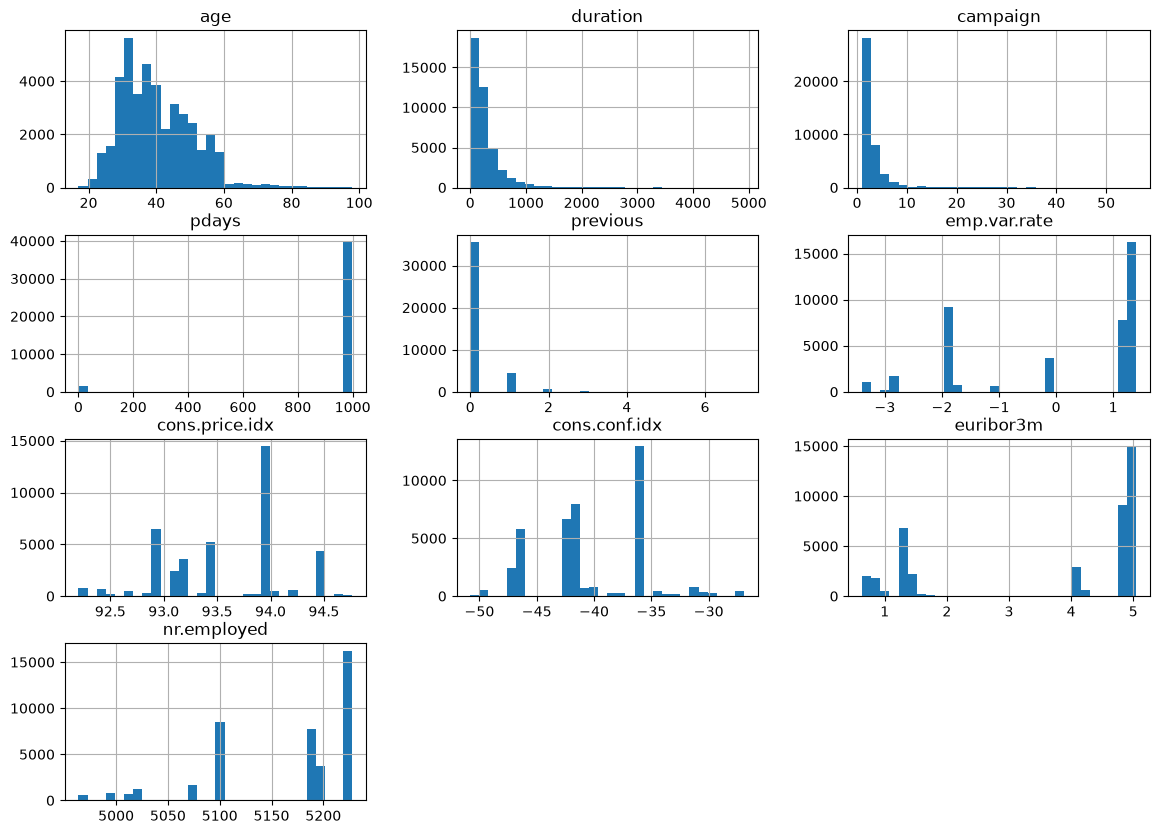

In [87]:
df[numeric_cols].hist(
    bins=30,
    figsize=(14, 10),
)

In [88]:
df["pdays"].value_counts().sort_index()

pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64

In [90]:
df["campaign"].value_counts().sort_index()

campaign
1     17642
2     10570
3      5341
4      2651
5      1599
6       979
7       629
8       400
9       283
10      225
11      177
12      125
13       92
14       69
15       51
16       51
17       58
18       33
19       26
20       30
21       24
22       17
23       16
24       15
25        8
26        8
27       11
28        8
29       10
30        7
31        7
32        4
33        4
34        3
35        5
37        1
39        1
40        2
41        1
42        2
43        2
56        1
Name: count, dtype: int64

In [91]:
df["previous"].value_counts().sort_index()

previous
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64

In [92]:
df[numeric_cols].quantile(
    [0.01, 0.05, 0.50, 0.95, 0.99]
)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0.01,23.0,11.00,1.0,3.0,0.0,-3.4,92.201,-49.5,0.65848,4963.6
0.05,26.0,36.00,1.0,999.0,0.0,-2.9,92.713,-47.1,0.79700,5017.5
0.50,38.0,180.00,2.0,999.0,0.0,1.1,93.749,-41.8,4.85700,5191.0
0.95,58.0,752.65,7.0,999.0,1.0,1.4,94.465,-33.6,4.96600,5228.1
0.99,71.0,1271.13,14.0,999.0,2.0,1.4,94.465,-26.9,4.96800,5228.1


### Numeric Feature Observations

- Several numeric variables are strongly right-skewed.
- `duration` contains a long right tail.
- `campaign` is concentrated at small values, with a small number of large values.
- `previous` is concentrated near zero.
- `pdays` contains a dominant sentinel value and should not be interpreted as an ordinary continuous variable.
- Macroeconomic variables have relatively narrow ranges and limited unique values.

### 5.2 Categorical Features

In [109]:
categorical_cols = df.select_dtypes(include="str").columns.tolist()
categorical_cols.remove("y")

categorical_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [110]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(normalize=True))


--- job ---
job
admin.           0.253035
blue-collar      0.224677
technician       0.163713
services         0.096363
management       0.070992
retired          0.041760
entrepreneur     0.035350
self-employed    0.034500
housemaid        0.025736
unemployed       0.024619
student          0.021244
unknown          0.008012
Name: proportion, dtype: float64

--- marital ---
marital
married     0.605225
single      0.280859
divorced    0.111974
unknown     0.001942
Name: proportion, dtype: float64

--- education ---
education
university.degree      0.295426
high.school            0.231014
basic.9y               0.146766
professional.course    0.127294
basic.4y               0.101389
basic.6y               0.055647
unknown                0.042027
illiterate             0.000437
Name: proportion, dtype: float64

--- default ---
default
no         0.791201
unknown    0.208726
yes        0.000073
Name: proportion, dtype: float64

--- housing ---
housing
yes        0.523842
no         0.45

<Axes: title={'center': 'Job Distribution'}, xlabel='job'>

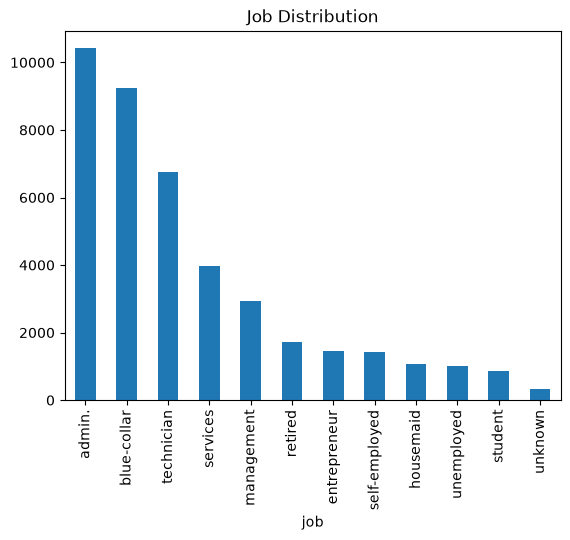

In [111]:
df["job"].value_counts().plot(
    kind="bar",
    title="Job Distribution",
)

<Axes: title={'center': 'Education Distribution'}, xlabel='education'>

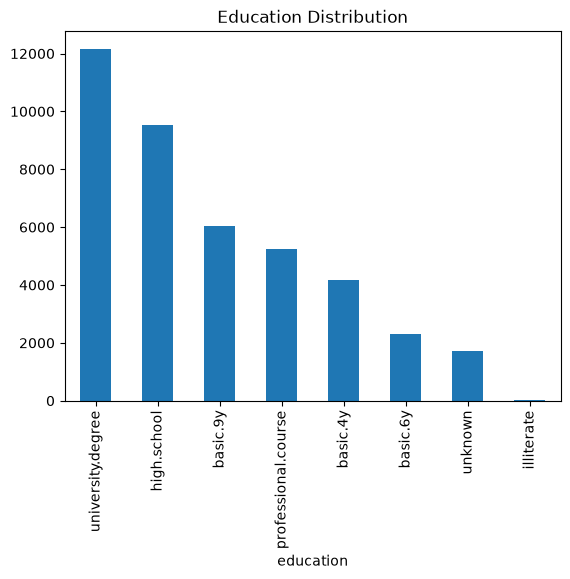

In [112]:
df["education"].value_counts().plot(
    kind="bar",
    title="Education Distribution",
)

<Axes: title={'center': 'Month Distribution'}, xlabel='month'>

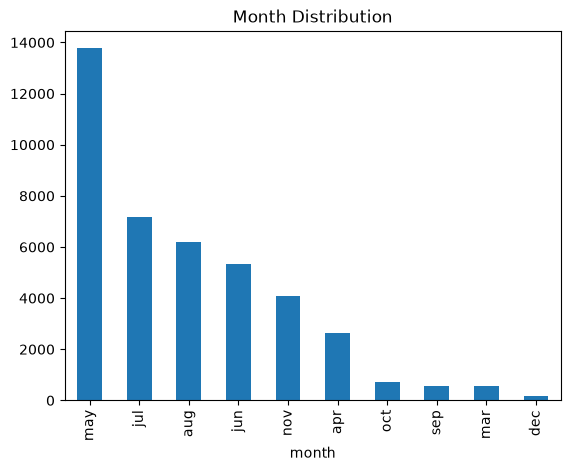

In [113]:
df["month"].value_counts().plot(
    kind="bar",
    title="Month Distribution",
)

### Categorical Feature Observations

- Several categorical variables contain an `unknown` category.
- `default` is highly concentrated in `no` and `unknown`, while `yes` is extremely rare.
- `education` contains a very rare `illiterate` category.
- `month` is strongly imbalanced, with a large concentration of observations in a few months.
- `day_of_week` is relatively balanced across weekdays.
- `poutcome` is dominated by `nonexistent`.

## 6. Feature-Target Analysis

This section examines how individual features are related to the target variable `y`.

The goals are to:

- compare target rates across categorical variables
- compare numeric feature distributions across target classes
- identify features with potentially strong predictive relationships
- flag relationships that may require leakage or feature-availability review

### 6.1 Categorical Features vs Target

In [114]:
pd.crosstab(
    df["job"],
    df["y"],
    normalize="index",
)

y,no,yes
job,,
admin.,0.870274,0.129726
blue-collar,0.931057,0.068943
entrepreneur,0.914835,0.085165
housemaid,0.900000,0.100000
management,0.887825,0.112175
retired,0.747674,0.252326
self-employed,0.895144,0.104856
services,0.918619,0.081381
student,0.685714,0.314286


In [125]:
df.assign(y_yes=(df.y == "yes").astype(int)).groupby("job")["y_yes"].agg(["mean", "count"]).sort_values("mean", ascending=False)

,mean,count
job,,
student,0.314286,875
retired,0.252326,1720
unemployed,0.142012,1014
admin.,0.129726,10422
management,0.112175,2924
unknown,0.112121,330
technician,0.108260,6743
self-employed,0.104856,1421
housemaid,0.100000,1060


In [115]:
categorical_features = [
    col for col in df.select_dtypes(include="str").columns
    if col != "y"
]

for col in categorical_features:
    target_rate = (
        df.assign(y_yes=(df["y"] == "yes").astype(int))
        .groupby(col)["y_yes"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )

    print(f"\n--- {col} ---")
    print(target_rate)


--- job ---
                   mean  count
job                           
student        0.314286    875
retired        0.252326   1720
unemployed     0.142012   1014
admin.         0.129726  10422
management     0.112175   2924
unknown        0.112121    330
technician     0.108260   6743
self-employed  0.104856   1421
housemaid      0.100000   1060
entrepreneur   0.085165   1456
services       0.081381   3969
blue-collar    0.068943   9254

--- marital ---
              mean  count
marital                  
unknown   0.150000     80
single    0.140041  11568
divorced  0.103209   4612
married   0.101573  24928

--- education ---
                         mean  count
education                           
illiterate           0.222222     18
unknown              0.145003   1731
university.degree    0.137245  12168
professional.course  0.113485   5243
high.school          0.108355   9515
basic.4y             0.102490   4176
basic.6y             0.082024   2292
basic.9y             0.07824

### Categorical Feature-Target Observations

- `job` shows meaningful differences in subscription rates across occupations.
  - `student` and `retired` have relatively high subscription rates.
  - `blue-collar` has a relatively low subscription rate.
- `marital` shows moderate differences, with `single` clients having a somewhat higher subscription rate.
- `education` shows variation across categories, but very small categories such as `illiterate` should be interpreted cautiously.
- `default` shows a strong difference between `no` and `unknown`, while the `yes` category is too rare to interpret reliably.
- `housing` and `loan` show only small differences in subscription rates.
- `contact` shows a large difference between `cellular` and `telephone`.
- `month` shows very large variation in subscription rates across months, suggesting strong temporal or campaign-related effects.
- `day_of_week` shows relatively small differences.
- `poutcome` is strongly associated with the target:
  - previous campaign `success` corresponds to a much higher subscription rate,
  - `failure` is intermediate,
  - `nonexistent` has the lowest rate among the three.

### Caution

Strong target association does not automatically imply that a feature is safe to use in production.

Features related to the current contact process or campaign timing, such as `contact` and `month`, should be reviewed later for feature availability and leakage.

### 5.2 Numeric Features vs Target

In [131]:
df.groupby("y")[numeric_cols].mean()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
y,,,,,,,,,,
no,39.911185,220.844807,2.633085,984.113878,0.132374,0.248875,93.603757,-40.593097,3.811491,5176.166600
yes,40.913147,553.191164,2.051724,792.035560,0.492672,-1.233448,93.354386,-39.789784,2.123135,5095.115991


In [132]:
df.groupby("y")[numeric_cols].median()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
y,,,,,,,,,,
no,38.0,163.5,2.0,999.0,0.0,1.1,93.918,-41.8,4.857,5195.8
yes,37.0,449.0,2.0,999.0,0.0,-1.8,93.200,-40.4,1.266,5099.1


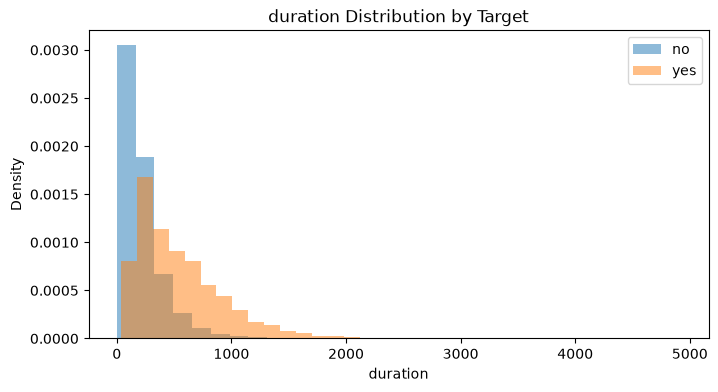

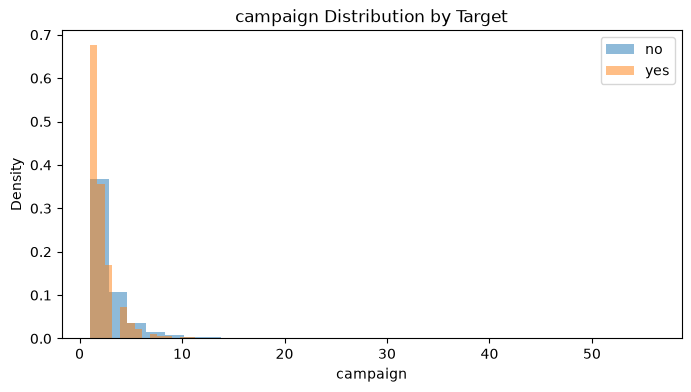

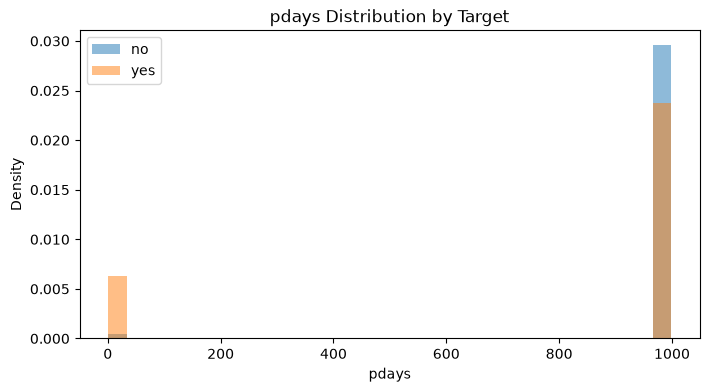

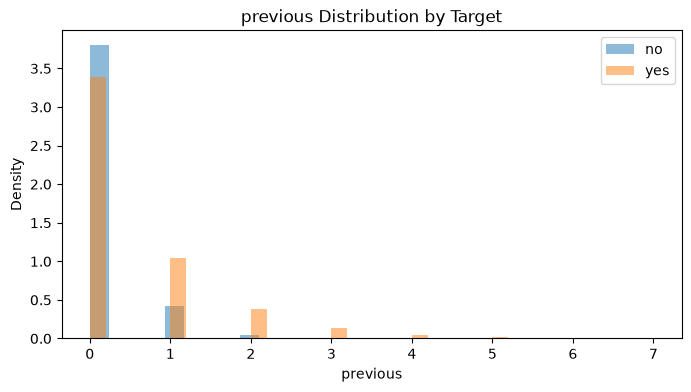

In [137]:
for col in ["duration", "campaign", "pdays", "previous"]:
    plt.figure(figsize=(8, 4))

    plt.hist(
        df.loc[df["y"] == "no", col],
        bins=30,
        alpha=0.5,
        density=True,
        label="no",
    )

    plt.hist(
        df.loc[df["y"] == "yes", col],
        bins=30,
        alpha=0.5,
        density=True,
        label="yes",
    )

    plt.title(f"{col} Distribution by Target")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()

    plt.show()

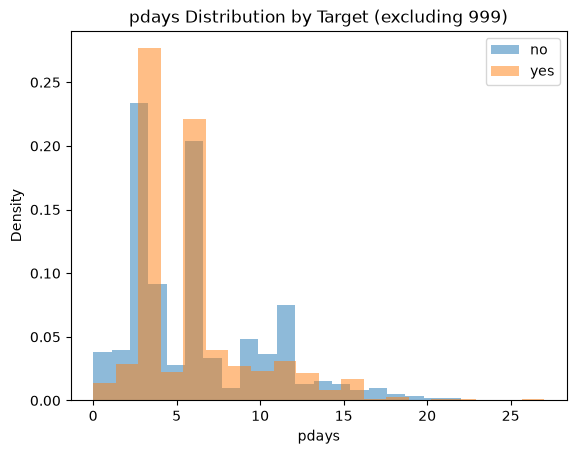

In [138]:
pdays_contacted = df[df["pdays"] != 999]

for target in ["no", "yes"]:
    plt.hist(
        pdays_contacted.loc[
            pdays_contacted["y"] == target,
            "pdays",
        ],
        bins=20,
        alpha=0.5,
        density=True,
        label=target,
    )

plt.title("pdays Distribution by Target (excluding 999)")
plt.xlabel("pdays")
plt.ylabel("Density")
plt.legend()
plt.show()

### Numeric Feature-Target Observations

- `duration` shows a very strong difference between target classes.
  Clients who subscribed have much longer average and median call durations.
- `campaign` shows a modest difference, with subscribed clients having slightly fewer contacts on average.
- `previous` is higher on average for subscribed clients, although the median is 0 for both classes.
- `pdays` shows a large difference in means, but both medians are 999, so the sentinel value dominates the distribution and simple summary statistics are difficult to interpret.
- Several macroeconomic variables differ substantially between the two target classes.
  In particular, `euribor3m`, `emp.var.rate`, and `nr.employed` are lower for subscribed clients.
- These macroeconomic differences may reflect temporal effects in the campaign period and should be considered when designing the train/validation/test split.

## 7. Feature-Feature Relationships

This section examines relationships among input features.

The goals are to:

- identify strongly correlated numeric variables
- detect potentially redundant information
- examine logically related feature groups
- understand whether multiple variables may represent the same underlying process

### 7.1 Numeric vs Numeric

In [139]:
corr_matrix = df[numeric_cols].corr()
corr_matrix

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


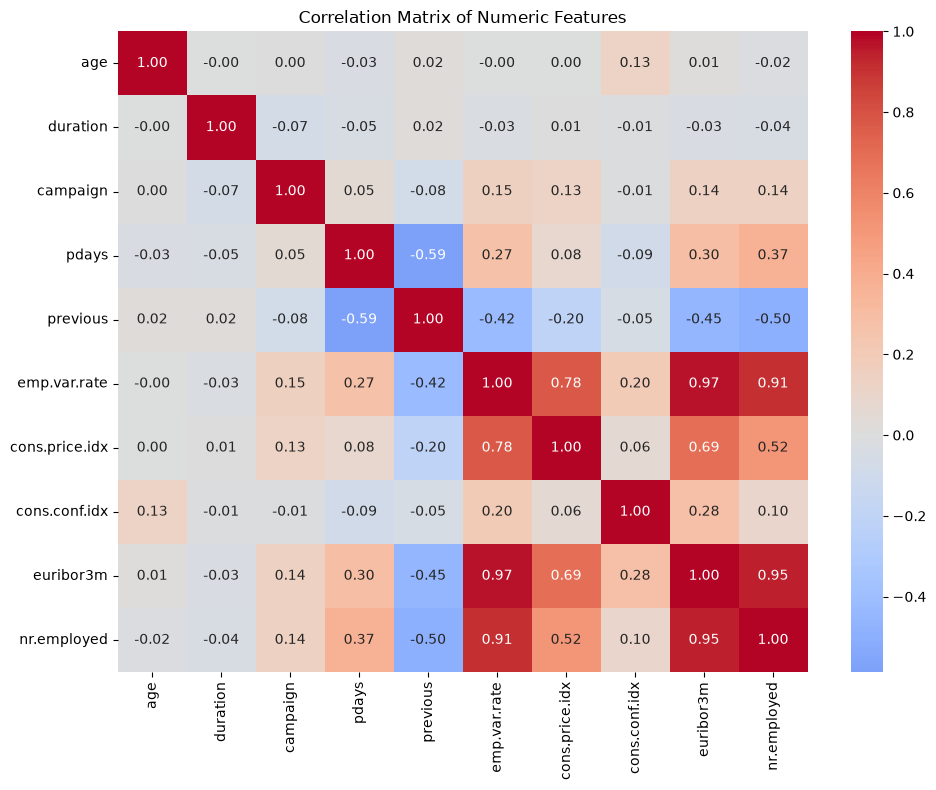

In [142]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

### Numeric Feature Relationship Observations

Pearson correlation was calculated for numeric features.

The correlation matrix is used to identify:

- strongly related numeric variables
- potentially redundant information
- groups of variables that may describe the same underlying process

High correlation alone is not used as a reason to remove a feature at this stage.
Feature removal decisions will be made later during modeling and evaluation.

### 7.2 Categorical ↔ Categorical

In [143]:
job_education = pd.crosstab(
    df["job"],
    df["education"],
    normalize="index",
)

job_education

education,basic.4y,basic.6y,basic.9y,high.school,illiterate,professional.course,university.degree,unknown
job,,,,,,,,
admin.,0.007388,0.014489,0.047879,0.319420,0.000096,0.034830,0.552005,0.023892
blue-collar,0.250486,0.154096,0.391506,0.094878,0.000864,0.048952,0.010158,0.049060
entrepreneur,0.094093,0.048764,0.144231,0.160714,0.001374,0.092720,0.418956,0.039148
housemaid,0.447170,0.072642,0.088679,0.164151,0.000943,0.055660,0.131132,0.039623
management,0.034200,0.029070,0.056772,0.101915,0.000000,0.030438,0.705540,0.042066
retired,0.347093,0.043605,0.084302,0.160465,0.001744,0.140116,0.165698,0.056977
self-employed,0.065447,0.017593,0.154821,0.083040,0.002111,0.118227,0.538353,0.020408
services,0.033258,0.056941,0.097758,0.675737,0.000000,0.054926,0.043588,0.037793
student,0.029714,0.014857,0.113143,0.408000,0.000000,0.049143,0.194286,0.190857


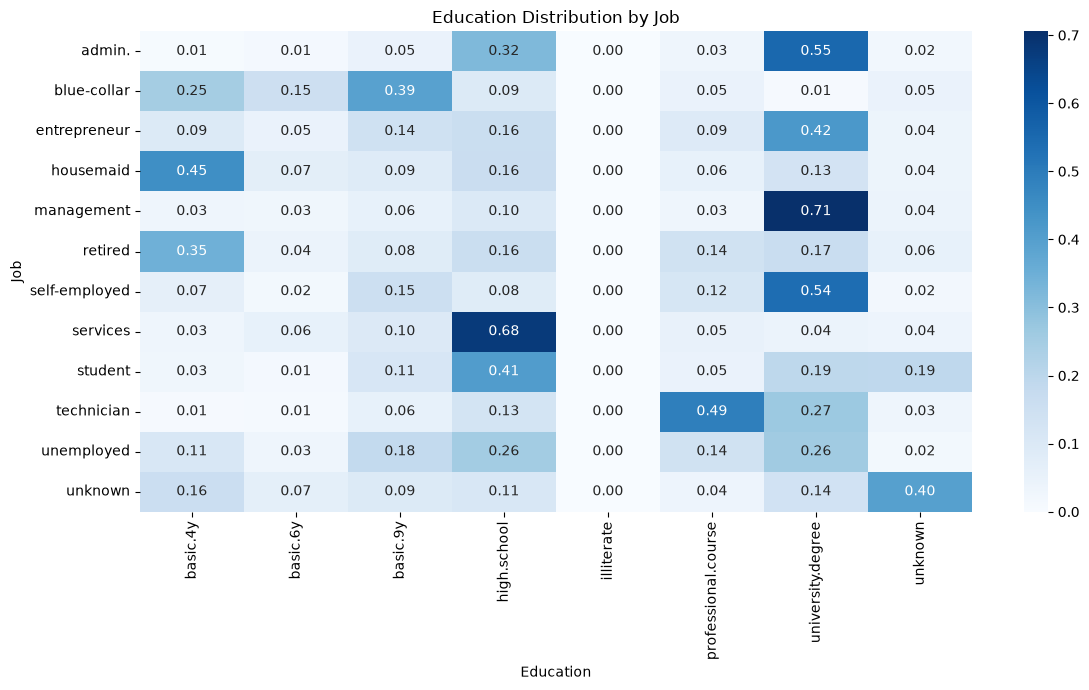

In [144]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    job_education,
    annot=True,
    fmt=".2f",
    cmap="Blues",
)

plt.title("Education Distribution by Job")
plt.xlabel("Education")
plt.ylabel("Job")
plt.tight_layout()
plt.show()

### Job-Education Relationship

The distribution of education varies substantially across job categories.

- `management` is dominated by `university.degree`.
- `admin.` also has a high proportion of `university.degree`.
- `blue-collar` workers are concentrated in the basic education categories.
- `services` is dominated by `high.school`.
- `technician` has a large proportion of `professional.course`.
- `housemaid` has a relatively large proportion of `basic.4y`.
- The `unknown` job category also shows a relatively high proportion of unknown education.

These patterns suggest that `job` and `education` are associated rather than independent.

However, this association alone is not sufficient to conclude that either feature is redundant.

### 7.3 Numeric vs Categorical

In [146]:
job_age_summary = (
    df.groupby("job")["age"]
    .agg(
        ["count", "mean", "median", "std"]
    )
    .sort_values("median")
)

job_age_summary

,count,mean,median,std
job,,,,
student,875,25.894857,25.0,4.991334
admin.,10422,38.187296,36.0,8.907151
services,3969,37.926430,36.0,9.018749
technician,6743,38.507638,37.0,8.660968
self-employed,1421,39.949331,39.0,9.422417
unemployed,1014,39.733728,39.0,9.267022
blue-collar,9254,39.555760,39.0,8.827396
entrepreneur,1456,41.723214,41.0,8.910840
management,2924,42.362859,42.0,9.303820


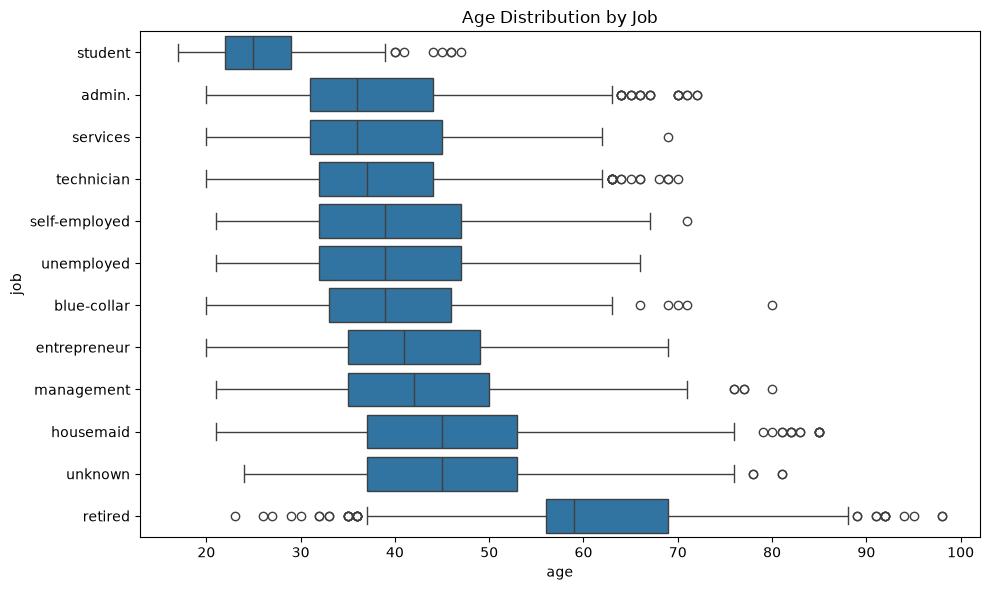

In [147]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="age",
    y="job",
    order=job_age_summary.index,
)

plt.title("Age Distribution by Job")
plt.tight_layout()
plt.show()

### Job-Age Relationship

Age distributions differ noticeably across job categories.

- `student` is concentrated at much younger ages.
- `retired` is concentrated at much older ages.
- Several other job categories are centered around the late 30s to early 40s.
- Despite differences in group centers, the within-group standard deviations suggest substantial overlap between many job categories.

This indicates that `job` and `age` are associated, but they are not necessarily redundant.

In [148]:
month_euribor = (
    df.groupby("month")["euribor3m"]
    .agg(
        ["count", "mean", "median", "std"]
    )
)

month_euribor

,count,mean,median,std
month,,,,
apr,2632,1.361070,1.4050,0.192424
aug,6178,4.300623,4.9640,1.508808
dec,182,0.865319,0.7150,0.637524
jul,7174,4.685678,4.9620,1.020523
jun,5318,4.256908,4.9590,1.456200
mar,546,1.162745,1.5100,0.505510
may,13769,3.293665,4.8560,1.779844
nov,4101,3.723123,4.1200,1.073368
oct,718,1.200123,0.7420,1.201280


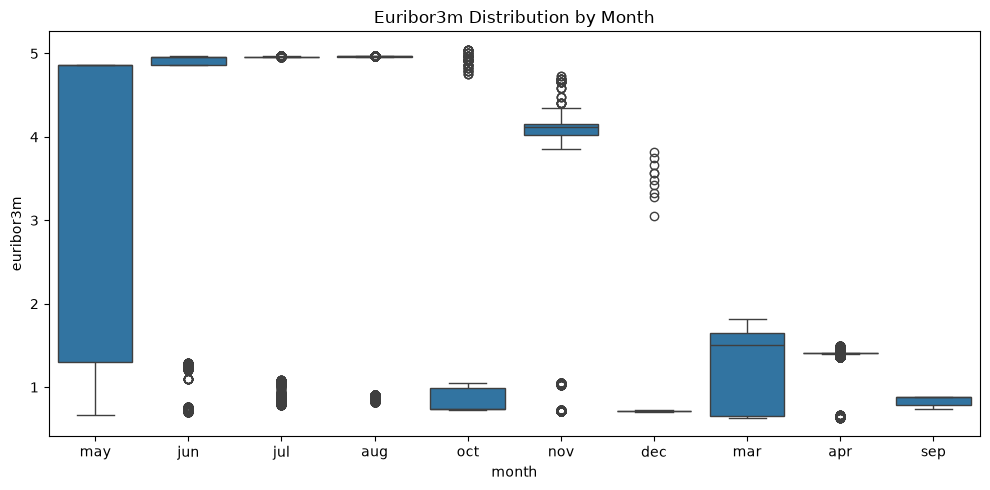

In [149]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="month",
    y="euribor3m",
)

plt.title("Euribor3m Distribution by Month")
plt.tight_layout()
plt.show()

### Month-Euribor3m Relationship

`euribor3m` varies substantially across months.

- Some months, such as `jul`, `aug`, and `jun`, have relatively high Euribor values.
- Other months, such as `sep`, `dec`, and `oct`, have much lower values.
- This suggests that `month` and `euribor3m` share temporal information.

However, `month` alone does not identify the full chronological order because the dataset spans multiple years.

This relationship should therefore be considered when designing the temporal split strategy.

In [151]:
poutcome_previous_summary = (
    df.groupby("poutcome")["previous"]
    .agg(
        ["count", "mean", "median", "std"]
    )
)

poutcome_previous_summary

,count,mean,median,std
poutcome,,,,
failure,4252,1.168627,1.0,0.486973
nonexistent,35563,0.000000,0.0,0.000000
success,1373,1.569556,1.0,0.904559


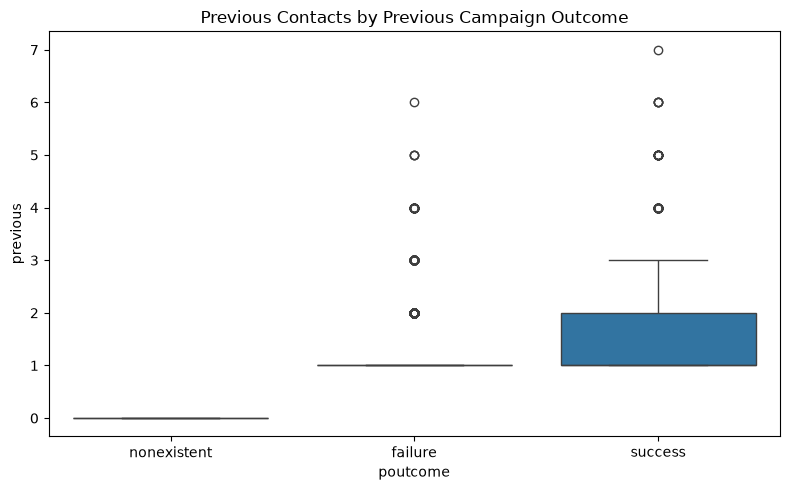

In [152]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="poutcome",
    y="previous",
)

plt.title("Previous Contacts by Previous Campaign Outcome")
plt.tight_layout()
plt.show()

### Poutcome-Previous Relationship

`poutcome` and `previous` show a strong structural relationship.

- When `poutcome = nonexistent`, `previous` is always 0.
- Clients with `poutcome = failure` or `success` have previous campaign contacts.
- The `success` group has a somewhat larger average number of previous contacts than the `failure` group.

This suggests that the two features share information about previous campaign history.

However, they are not identical:

- `previous` measures the number of previous contacts.
- `poutcome` records the outcome of the previous campaign.

Therefore, both features may still provide distinct information to a model.